# FIT5149 Assessment 1: Final Model Implementation

Group 43. Final model: **two-stage CatBoost, used in Kaggle attempt 4**.

We split the prediction into two questions: is the application likely to receive a loan, and what share of the requested amount might be approved? We then combine these estimates to predict the amount in AUD.

This notebook contains the final model and its checks. The EDA and model comparisons are kept in `development/`; the written report is a separate PDF.

Attempt 4 achieved a public RMSE of **33,096.96156**. The later three-seed average scored **33,119.70974** and had mixed validation results, so we have kept the simpler attempt 4 model. The public score is not the final private score.


In [1]:
# Imports and reproducibility settings
from pathlib import Path
import os
import platform
import sys
import time

# Limit background workers on this computer; this does not choose model settings.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import catboost

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, CatBoostRegressor

# Keep the same seed and folds when comparing results.
RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# RMSE gives more weight to large errors and is measured in AUD here.
def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


Matplotlib is building the font cache; this may take a moment.


## 1. Load the supplied data

The notebook expects `training_set.csv`, `kaggle_test_X.csv`, and `sample_submission.csv` in the same directory as the notebook.


In [2]:
# Read the data from the notebook folder.
DATA_DIR = Path.cwd()

# Also support the earlier assignment-folder layout.
if not (DATA_DIR / "training_set.csv").exists():
    candidate = Path.cwd() / "Assignment" / "A1"
    if (candidate / "training_set.csv").exists():
        DATA_DIR = candidate

train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Kaggle test:   {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Submission:    {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")


Training data: 19,322 rows x 29 columns
Kaggle test:   10,000 rows x 28 columns
Submission:    10,000 rows x 2 columns


## 2. Check the input files

Before training, we check the number of rows, column names, dates, and application IDs. This helps us catch a wrong input file or a submission template with a different row order.


In [3]:
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

# Check that the files have the expected structure and ID order.
assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

# Read dates as day/month/year and stop if a value cannot be parsed.
train_dates = pd.to_datetime(
    train["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)
test_dates = pd.to_datetime(
    test["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)

integrity_checks = pd.Series({
    "training_rows": len(train),
    "test_rows": len(test),
    "duplicate_training_rows": int(train.duplicated().sum()),
    "duplicate_test_rows": int(test.duplicated().sum()),
    "duplicate_training_ids": int(train["application_id"].duplicated().sum()),
    "duplicate_test_ids": int(test["application_id"].duplicated().sum()),
    "shared_ids_between_train_and_test": int(
        train["application_id"].isin(test["application_id"]).sum()
    ),
    "training_date_min": train_dates.min().date(),
    "training_date_max": train_dates.max().date(),
    "test_date_min": test_dates.min().date(),
    "test_date_max": test_dates.max().date(),
})

print("All schema and identifier checks passed.")
display(integrity_checks)


All schema and identifier checks passed.


training_rows                             19322
test_rows                                 10000
duplicate_training_rows                       0
duplicate_test_rows                           0
duplicate_training_ids                        0
duplicate_test_ids                            0
shared_ids_between_train_and_test             0
training_date_min                    2023-01-01
training_date_max                    2024-12-30
test_date_min                        2023-01-01
test_date_max                        2024-12-30
dtype: object

## 3. Understand the target

The target is the sanctioned loan amount in AUD. About 26.8% of training applications received zero. For the others, the amount is close to a small set of proportions of the requested loan.

We calculate `sanction_rate = sanctioned_amount / requested_amount` and round it to two decimals to identify these groups. We use the groups to balance the validation folds. The actual sanction rate is never included in the input features.


In [4]:
# Keep the target separate from the input features.
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
requested_array = requested.to_numpy()

assert (requested > 0).all()

# The observed rates form the groups used to balance validation folds.
sanction_rate = (y / requested).round(2).astype(float)

target_checks = pd.Series({
    "zero_target_n": int((y == 0).sum()),
    "zero_target_pct": 100 * (y == 0).mean(),
    "sanction_above_request_n": int((y > requested).sum()),
    "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
})

display(target_checks)


zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

## 4. Clean the data and create features

We keep the cleaning decisions from our EDA. We replace confirmed `-999` missing-value codes, record which values are missing, and create ratios that compare the loan request with income and property value.

Each calculation uses values from the same application. We do not fill numeric gaps using averages from the full dataset: CatBoost can handle numeric missing values. Missing categories are given a separate label.

The date features use sine and cosine so that dates near the end and start of the year are represented as close together. This is less familiar than the other cleaning steps, but it is still just a way of representing the calendar, not another model.


In [5]:
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

# Use the same missing-value indicator columns for training and test data.
MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]

def engineer_features(frame):
    x = frame.copy()

    # The EDA showed that -999 means missing in these three columns.
    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    # Keep a count and yes/no flags, since missing information may be useful.
    x["missing_value_count"] = x.isna().sum(axis=1)

    for column in MISSING_INDICATOR_COLUMNS:
        x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    # Represent the calendar without treating December and January as far apart.
    application_date = pd.to_datetime(
        x.pop("application_date"),
        format="%d/%m/%Y",
        errors="raise",
    )

    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_month_cos"] = np.cos(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    # Put both income fields on an annual scale, then combine them within each row.
    income_candidates = pd.concat(
        [
            x["annual_income_aud"],
            12 * x["monthly_income_aud"],
        ],
        axis=1,
    )

    x["annual_income_reconciled_aud"] = income_candidates.median(
        axis=1,
        skipna=True,
    )
    x["income_sources_available"] = income_candidates.notna().sum(axis=1)

    # Record disagreement between the two reported income values.
    x["income_relative_gap"] = (
        (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    # Compare loan size with income and property value.
    # Replace zero denominators with missing values to avoid division by zero.
    x["requested_to_property_value"] = (
        x["requested_amount_aud"]
        / x["property_value_aud"].replace(0, np.nan)
    )

    x["requested_to_annual_income"] = (
        x["requested_amount_aud"]
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    x["repayments_to_monthly_income"] = (
        x["existing_repayments_aud"]
        / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
    )

    x["property_value_minus_requested"] = (
        x["property_value_aud"] - x["requested_amount_aud"]
    )

    # Drop IDs and the unreliable property-age values identified in the EDA.
    # Its missing-value flag is kept; property_ref was excluded during development.
    x = x.drop(
        columns=[
            "application_id",
            "property_age_years",
            "property_ref",
        ]
    )

    return x

X_selected = engineer_features(train.drop(columns=TARGET))
X_kaggle_selected = engineer_features(test)

assert X_selected.columns.tolist() == X_kaggle_selected.columns.tolist()
assert not np.isinf(
    X_selected.select_dtypes(include="number").to_numpy()
).any()

selected_categorical_features = (
    X_selected
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

# Give missing categories a label that CatBoost can read.
# Numeric gaps stay as NaN.
for column in selected_categorical_features:
    X_selected[column] = (
        X_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

    X_kaggle_selected[column] = (
        X_kaggle_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

print(f"Final predictor count: {X_selected.shape[1]}")
print(f"Categorical predictors: {len(selected_categorical_features)}")


Final predictor count: 49
Categorical predictors: 12


## 5. Set up validation

We use five folds with a fixed random seed. In each round, the models train on four folds and predict the remaining fold. Every training application gets a prediction from models that did not train on that application.

`StratifiedKFold` keeps similar proportions of the sanction-rate groups in each fold, including the rare groups. We reuse the same folds from the earlier comparisons. These are development results used to choose models, not an independent test set.


In [6]:
# Use each observed rate as a group label, not as a predictor.
strata = sanction_rate.map(lambda value: f"{value:.2f}")

splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

folds = list(
    splitter.split(
        X_selected,
        strata,
    )
)

# Check that the five validation groups have similar rate proportions.
fold_balance = []

for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = (
        strata.iloc[valid_index]
        .value_counts(normalize=True)
        .sort_index()
    )
    fold_balance.append(
        counts.rename(f"fold_{fold_number}")
    )

display(
    pd.concat(fold_balance, axis=1)
    .T
    .style
    .format("{:.2%}")
)


,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


## 6. Fit the two-stage model

This is the main advanced part of the notebook:

1. A CatBoost classifier estimates the probability of a positive sanctioned amount using all fitting rows.
2. A CatBoost regressor estimates the sanction rate using only the approved fitting rows.
3. We multiply the approval probability, predicted positive rate, and requested amount.

For example, a probability of 0.8 and a predicted positive rate of 0.7 give an expected amount of `0.8 * 0.7 * requested_amount`. We keep the probability instead of forcing an approve/reject decision at 0.5.

The approval model uses depth 5 and 1,200 iterations. The rate model uses depth 4 and 800 iterations. The functions below are reused for validation and for the final fit, so both follow the same steps.


In [7]:
# These are the settings used for attempt 4. No tuning happens in this notebook.
MODEL_NAME = 'catboost_two_stage'
MODEL_PARAMS = {
    "depth": 5,
    "iterations": 1200,
    "learning_rate": 0.03,
    "l2_leaf_reg": 10.0,
    "random_seed": 42,
    "thread_count": 6,
    "verbose": False,
    "allow_writing_files": False,
}

# Keep the exact predictor names and order used in attempt 4.
PREDICTOR_COLUMNS = [
    "applicant_gender",
    "applicant_age",
    "annual_income_aud",
    "income_consistency",
    "occupation_class",
    "employment_sector",
    "residence_area",
    "requested_amount_aud",
    "existing_repayments_aud",
    "expense_flag_a",
    "expense_flag_b",
    "dependants_count",
    "credit_rating",
    "prior_default_count",
    "card_status",
    "property_category",
    "property_area",
    "has_co_applicant",
    "property_value_aud",
    "marketing_channel",
    "branch_id",
    "monthly_income_aud",
    "risk_review_flag",
    "enquiry_count_12m",
    "missing_value_count",
    "applicant_gender_is_missing",
    "annual_income_aud_is_missing",
    "income_consistency_is_missing",
    "employment_sector_is_missing",
    "existing_repayments_aud_is_missing",
    "dependants_count_is_missing",
    "credit_rating_is_missing",
    "property_age_years_is_missing",
    "property_area_is_missing",
    "has_co_applicant_is_missing",
    "property_value_aud_is_missing",
    "monthly_income_aud_is_missing",
    "application_year",
    "application_month_sin",
    "application_month_cos",
    "application_dayofyear_sin",
    "application_dayofyear_cos",
    "annual_income_reconciled_aud",
    "income_sources_available",
    "income_relative_gap",
    "requested_to_property_value",
    "requested_to_annual_income",
    "repayments_to_monthly_income",
    "property_value_minus_requested",
]
MODEL_CATEGORIES = [c for c in selected_categorical_features if c in PREDICTOR_COLUMNS]

def fit_final_model(features, amounts):
    # During validation, these are only the training rows for the current fold.
    requested_amounts = features["requested_amount_aud"].to_numpy()
    rates = (np.asarray(amounts) / requested_amounts).round(2)
    approved = np.asarray(amounts) > 0
    predictors = features[PREDICTOR_COLUMNS]

    # 1. Learn whether an application receives a positive amount.
    approval_model = CatBoostClassifier(loss_function="Logloss", **MODEL_PARAMS)
    approval_model.fit(predictors, approved.astype(int), cat_features=MODEL_CATEGORIES)

    # 2. Learn the approved share using positive cases only.
    rate_params = dict(MODEL_PARAMS, depth=4, iterations=800)
    rate_model = CatBoostRegressor(loss_function="RMSE", **rate_params)
    rate_model.fit(predictors.loc[approved], rates[approved], cat_features=MODEL_CATEGORIES)
    return approval_model, rate_model


def predict_final_model(models, features):
    approval_model, rate_model = models
    predictors = features[PREDICTOR_COLUMNS]
    # Find the probability column for approval (class 1).
    positive_column = list(approval_model.classes_).index(1)
    approval_probability = approval_model.predict_proba(predictors)[:, positive_column]
    positive_rate = np.clip(rate_model.predict(predictors), 0, 1)
    requested_amounts = features["requested_amount_aud"].to_numpy()
    # 3. Convert the two estimates into an expected amount in AUD.
    prediction = requested_amounts * approval_probability * positive_rate
    # Training amounts were never negative or above the requested loan.
    return np.clip(prediction, 0, requested_amounts)


## 7. Measure validation error and check five inputs

We calculate RMSE and MAE in AUD. Mean fold RMSE averages the five fold scores. Global out-of-fold (OOF) RMSE uses all held-out predictions together, so it can be slightly different.

We also shuffle one input at a time in the validation rows, keeping the trained model fixed. If the error rises, the model was using information from that input. We repeat this three times per input and fold to reduce dependence on one shuffle.

We check five inputs highlighted by the EDA, not all 49 features. This does not prove causation. Related features may contain overlapping information. Requested amount also sets the scale of the final prediction, so shuffling it affects both the model inputs and the conversion back to AUD.


In [8]:
validation_rows = []
permutation_rows = []
# OOF stores one held-out prediction for every training application.
final_oof = np.full(len(train), np.nan)
FEATURES_TO_CHECK = [
    "requested_amount_aud", "has_co_applicant", "credit_rating",
    "income_consistency", "applicant_age",
]
started = time.time()

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
    # Fit on this fold's training rows, then predict its held-out rows.
    fitted_model = fit_final_model(X_selected.iloc[train_index], y.iloc[train_index])
    validation_x = X_selected.iloc[valid_index]
    prediction = predict_final_model(fitted_model, validation_x)
    final_oof[valid_index] = prediction
    fold_rmse = rmse(y.iloc[valid_index], prediction)
    validation_rows.append({
        "fold": fold_number,
        "rmse_aud": fold_rmse,
        "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction),
    })
    print(f"Fold {fold_number}: RMSE ${fold_rmse:,.2f}")

    # Shuffle validation inputs only. Do not refit the model for this check.
    for feature_number, feature in enumerate(FEATURES_TO_CHECK):
        for repeat in range(3):
            shuffled = validation_x.copy()
            # Give each shuffle a different but repeatable seed.
            rng = np.random.default_rng(
                RANDOM_STATE + 1000 * fold_number + 10 * feature_number + repeat
            )
            shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
            shuffled_prediction = predict_final_model(fitted_model, shuffled)
            permutation_rows.append({
                "feature": feature, "fold": fold_number, "repeat": repeat + 1,
                "rmse_increase_aud": rmse(y.iloc[valid_index], shuffled_prediction) - fold_rmse,
            })

# Make sure every row received a valid held-out prediction.
assert np.isfinite(final_oof).all()
validation_detail = pd.DataFrame(validation_rows)
validation_summary = pd.Series({
    "mean_fold_rmse_aud": validation_detail["rmse_aud"].mean(),
    "sd_fold_rmse_aud": validation_detail["rmse_aud"].std(),
    "global_oof_rmse_aud": rmse(y, final_oof),
    "mae_aud": mean_absolute_error(y, final_oof),
    "validation_seconds": time.time() - started,
})
permutation_detail = pd.DataFrame(permutation_rows)
# Average the three shuffles within each fold before comparing folds.
permutation_by_fold = (
    permutation_detail.groupby(["feature", "fold"])["rmse_increase_aud"].mean()
)
permutation_summary = (
    permutation_by_fold.groupby("feature")
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)
display(validation_summary)
display(permutation_summary)


Fold 1: RMSE $32,393.77


Fold 2: RMSE $34,388.31


Fold 3: RMSE $34,920.65


Fold 4: RMSE $33,013.18


Fold 5: RMSE $35,077.95


mean_fold_rmse_aud    33,958.773
sd_fold_rmse_aud       1,194.324
global_oof_rmse_aud   33,975.512
mae_aud               16,850.524
validation_seconds        54.589
dtype: float64

,mean,std
feature,,
requested_amount_aud,"51,198.693","1,842.106"
credit_rating,"20,197.501","1,872.842"
has_co_applicant,"17,953.143",903.864
income_consistency,"1,355.691",489.275
applicant_age,59.876,40.817


## 8. Check where the model makes larger errors

We use the held-out predictions to compare errors for approved and rejected applications, missing and available credit ratings, and five groups of requested loan sizes.

The signed error is `actual - predicted`: a positive value means the model predicted too little. We also show the number of rows, since results for small groups are less reliable.


approved


,rows,rmse_aud,mae_aud,mean_error_aud
approved,,,,
False,"5,177.000","58,764.555","30,374.433","-30,374.433"
True,"14,145.000","17,689.988","11,900.840","10,971.306"


credit_missing


,rows,rmse_aud,mae_aud,mean_error_aud
credit_missing,,,,
False,"15,369.000","32,006.060","15,061.232",-285.428
True,"3,953.000","40,737.733","23,807.173",588.775


request_band


,rows,rmse_aud,mae_aud,mean_error_aud
request_band,,,,
"(9467.479, 58154.086]","3,865.000","9,013.715","5,117.973",-205.488
"(58154.086, 97642.096]","3,864.000","15,764.527","9,203.624",-55.649
"(97642.096, 139523.094]","3,864.000","24,143.644","14,435.146",136.358
"(139523.094, 204700.392]","3,864.000","36,482.391","21,963.785",-571.952
"(204700.392, 933695.43]","3,865.000","59,394.384","33,530.812",163.793


sanction_rate


,rows,rmse_aud,mae_aud,mean_error_aud
sanction_rate,,,,
0.000,"5,177.000","58,764.555","30,374.433","-30,374.433"
0.650,"3,257.000","9,815.447","6,700.674","5,957.119"
0.700,"5,686.000","14,003.444","10,601.920","8,964.288"
0.750,"2,568.000","17,117.252","12,278.210","11,727.227"
0.800,"2,502.000","25,337.684","19,674.179","19,674.179"
0.850,42.000,"81,820.807","34,292.579","34,292.579"
0.900,50.000,"65,605.009","41,033.787","41,033.787"
1.000,40.000,"59,707.937","49,588.888","49,588.888"


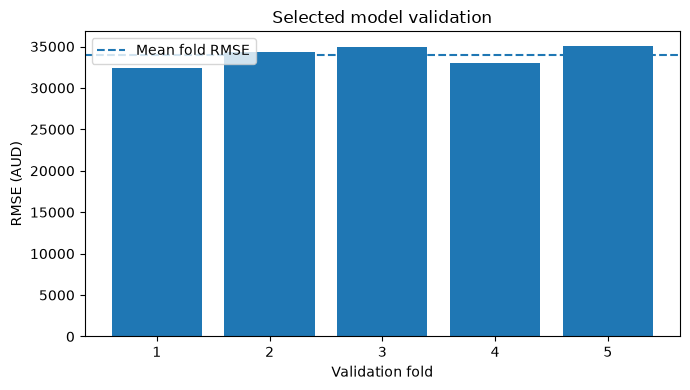

In [9]:
# Use validation predictions, not predictions on the rows used for fitting.
diagnostics = pd.DataFrame({
    "actual": y,
    "prediction": final_oof,
    "requested_amount_aud": train["requested_amount_aud"],
    "sanction_rate": sanction_rate,
    "credit_missing": train["credit_rating"].isna(),
    "approved": y > 0,
})
# Split loan requests into five groups with roughly equal numbers of rows.
diagnostics["request_band"] = pd.qcut(diagnostics["requested_amount_aud"], 5)
diagnostics["error"] = diagnostics["actual"] - diagnostics["prediction"]

# Reuse the same error measures for each group.
def error_summary(group):
    return pd.Series({
        "rows": len(group),
        "rmse_aud": rmse(group["actual"], group["prediction"]),
        "mae_aud": mean_absolute_error(group["actual"], group["prediction"]),
        "mean_error_aud": group["error"].mean(),
    })

for group_column in ["approved", "credit_missing", "request_band", "sanction_rate"]:
    print(group_column)
    display(diagnostics.groupby(group_column, observed=True).apply(error_summary, include_groups=False))

# Compare the five fold errors with their average.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(validation_detail["fold"].astype(str), validation_detail["rmse_aud"])
ax.axhline(validation_summary["mean_fold_rmse_aud"], linestyle="--", label="Mean fold RMSE")
ax.set(xlabel="Validation fold", ylabel="RMSE (AUD)", title="Selected model validation")
ax.legend()
plt.tight_layout()
plt.show()


### What these results show

The two-stage model still struggles with rejected applications. Their RMSE is about AUD 58,765, compared with AUD 17,690 for approved applications. It sometimes assigns a positive expected amount to a case that was rejected, particularly when the available information leaves the decision uncertain.

Missing credit ratings are another limitation: RMSE is about AUD 40,738 when the rating is missing and AUD 32,006 when it is available. Errors also grow with loan size, from about AUD 9,014 in the smallest requested-amount group to AUD 59,394 in the largest. Before using this model in practice, we would want better credit information and closer review of large or uncertain applications.

Among the five inputs checked, requested amount, credit rating, and co-applicant status have the largest effects when shuffled. Requested amount also controls the conversion to dollars, so its effect reflects the whole prediction process. Applicant age has a much smaller effect in this model. These checks support the EDA, but do not establish causation or rank all 49 inputs.

## 9. Retrain on all labelled data and create submission.csv

We now fit the same selected model on all labelled rows. The exported predictions must match the Kaggle entry nominated for the final assessment. All format and range checks run before saving the file.

In [10]:
# Validation is finished. Fit the same model on all labelled applications.
final_model = fit_final_model(X_selected, y)
final_prediction = predict_final_model(final_model, X_kaggle_selected).round(2)
# Preserve the IDs and row order expected by Kaggle.
submission = sample_submission[["application_id"]].copy()
submission[TARGET] = final_prediction

# Check the output before writing the final CSV.
assert submission.shape == (10000, 2)
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission["application_id"].equals(test["application_id"])
assert submission["application_id"].is_unique
assert np.isfinite(submission[TARGET]).all()
assert submission[TARGET].between(0, test["requested_amount_aud"]).all()

# This is the file paired with the final notebook for attempt 4.
submission_path = DATA_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved {submission_path.name}: {len(submission):,} checked predictions.")
display(submission.head())


Saved submission.csv: 10,000 checked predictions.


,application_id,sanctioned_amount_aud
0,LN-029039,"67,236.480"
1,LN-006880,"29,707.880"
2,LN-000529,"104,846.940"
3,LN-002049,"173,135.080"
4,LN-000921,688.330


## 10. Record the software versions

These versions and the fixed seed help us rerun the notebook in the same environment. Before submitting, restart the kernel and run all cells from top to bottom.


In [11]:
versions = pd.Series({
    "Python": sys.version.split()[0],
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "CatBoost": catboost.__version__,
    "random_seed": RANDOM_STATE,
    "validation_folds": N_SPLITS,
    "final_output": "submission.csv",
})

display(versions)


Python                                   3.11.15
Platform            macOS-26.6.2-arm64-arm-64bit
NumPy                                      2.4.6
pandas                                     3.0.5
scikit-learn                               1.9.0
CatBoost                                  1.2.10
random_seed                                   42
validation_folds                               5
final_output                      submission.csv
dtype: object